# Research Pipeline: Data Loading, Sampling, Preprocessing, and LIME Attribution
This notebook loads SNLI and CommonsenseQA datasets, samples subsets, preprocesses them for attribution, and runs LIME explanations on SNLI examples.

Done for 300 samples of snli without stop words


#### Set Up Data Paths & Directories

In [19]:
import os

from datasets import load_dataset, load_from_disk

# Set your base data directory
CWD = os.getcwd()
DATA_DIR = os.path.join(CWD, "data")

## Load Datasets (with Local Cache)
Load CommonsenseQA and SNLI datasets from disk if available, otherwise download and cache them locally.

In [20]:
# For CommonsenseQA
CSQA_PATH = os.path.join(DATA_DIR, "commonsenseqa_local")
if os.path.exists(CSQA_PATH):
    csqa = load_from_disk(CSQA_PATH)
else:
    csqa = load_dataset("commonsense_qa", cache_dir=DATA_DIR)
    csqa.save_to_disk(CSQA_PATH)

# For SNLI
SNLI_PATH = os.path.join(DATA_DIR, "snli_local")
if os.path.exists(SNLI_PATH):
    snli = load_from_disk(SNLI_PATH)
else:
    snli = load_dataset("snli", cache_dir=DATA_DIR)
    snli.save_to_disk(SNLI_PATH)


## Preview Dataset Structure and Sample
Display sample entries from SNLI and CommonsenseQA for sanity checking.

In [21]:
# Print Sample from Each Dataset

# Preview SNLI sample
print("SNLI sample:", snli['train'][0])

# Preview CommonsenseQA sample
print("\nCommonsenseQA structure:")
print(csqa)
print("\nSample CommonsenseQA example:")
example = csqa['train'][0]
for key, value in example.items():
    print(f"{key}: {value}")

SNLI sample: {'premise': 'A person on a horse jumps over a broken down airplane.', 'hypothesis': 'A person is training his horse for a competition.', 'label': 1}

CommonsenseQA structure:
DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'question_concept', 'choices', 'answerKey'],
        num_rows: 9741
    })
    validation: Dataset({
        features: ['id', 'question', 'question_concept', 'choices', 'answerKey'],
        num_rows: 1221
    })
    test: Dataset({
        features: ['id', 'question', 'question_concept', 'choices', 'answerKey'],
        num_rows: 1140
    })
})

Sample CommonsenseQA example:
id: 075e483d21c29a511267ef62bedc0461
question: The sanctions against the school were a punishing blow, and they seemed to what the efforts the school had made to change?
question_concept: punishing
choices: {'label': ['A', 'B', 'C', 'D', 'E'], 'text': ['ignore', 'enforce', 'authoritarian', 'yell at', 'avoid']}
answerKey: A


## Sample 300 Examples from Each Dataset
Randomly sample 300 valid examples from SNLI and CommonsenseQA for fast experimentation.

In [22]:
import random
random.seed(42)

NUM_CSQA = 300
NUM_SNLI = 300

# --- CommonsenseQA sampling ---
csqa_indices = random.sample(range(len(csqa['train'])), NUM_CSQA)
commonsense_examples = []
for i in csqa_indices:
    example = csqa['train'][i]
    commonsense_examples.append({
        'id': i,
        'question': example['question'],
        'choices': example['choices']['text'],
        'answer': example['answerKey'],
        'dataset': 'csqa'
    })

# --- SNLI sampling (valid only) ---
valid_snli_indices = [i for i, ex in enumerate(snli['train']) if ex['label'] != -1]
snli_indices = random.sample(valid_snli_indices, NUM_SNLI)
snli_examples = []
for i in snli_indices:
    example = snli['train'][i]
    snli_examples.append({
        'id': i,
        'premise': example['premise'],
        'hypothesis': example['hypothesis'],
        'label': example['label'],
        'dataset': 'snli'
    })

## Save Sampled Subsets to Disk
Save both JSON and pretty TXT files for annotation or downstream usage.

In [23]:
import json

SAMPLE_DIR = os.path.join(DATA_DIR, "sampled_examples")
os.makedirs(SAMPLE_DIR, exist_ok=True)

LABEL_NAMES = ['entailment', 'neutral', 'contradiction']

# JSON: Separate files
csqa_sample_path = os.path.join(SAMPLE_DIR, "csqa_sample.json")
with open(csqa_sample_path, "w", encoding="utf-8") as f:
    json.dump(commonsense_examples, f, indent=4, ensure_ascii=False)
print(f"✅ Saved {len(commonsense_examples)} CommonsenseQA examples to: {csqa_sample_path}")

snli_sample_path = os.path.join(SAMPLE_DIR, "snli_sample.json")
with open(snli_sample_path, "w", encoding="utf-8") as f:
    json.dump(snli_examples, f, indent=4, ensure_ascii=False)
print(f"✅ Saved {len(snli_examples)} SNLI examples to: {snli_sample_path}")

# TXT: Human-readable annotation format
csqa_sample_txt_path = os.path.join(SAMPLE_DIR, "csqa_sample.txt")
with open(csqa_sample_txt_path, "w", encoding="utf-8") as f:
    f.write("=== CommonsenseQA Sample ===\n\n")
    for ex in commonsense_examples:
        f.write(f"ID: {ex['id']}\n")
        f.write(f"Question: {ex['question']}\n")
        f.write(f"Choices: {ex['choices']}\n")
        f.write(f"Answer: {ex['answer']}\n")
        f.write("-" * 60 + "\n")
print(f"✅ Saved {len(commonsense_examples)} readable subset to: {csqa_sample_txt_path}")

snli_sample_txt_path = os.path.join(SAMPLE_DIR, "snli_sample.txt")
with open(snli_sample_txt_path, "a", encoding="utf-8") as f:
    f.write("\n=== SNLI Sample ===\n\n")
    for ex in snli_examples:
        f.write(f"ID: {ex['id']}\n")
        f.write(f"Premise: {ex['premise']}\n")
        f.write(f"Hypothesis: {ex['hypothesis']}\n")
        f.write(f"Label: {LABEL_NAMES[ex['label']]}\n")
        f.write("-" * 60 + "\n")
print(f"✅ Saved {len(snli_examples)} readable subset to: {snli_sample_txt_path}")


✅ Saved 300 CommonsenseQA examples to: c:\Users\Work\OneDrive\Desktop\ChatGPT\Research\project\data\sampled_examples\csqa_sample.json
✅ Saved 300 SNLI examples to: c:\Users\Work\OneDrive\Desktop\ChatGPT\Research\project\data\sampled_examples\snli_sample.json
✅ Saved 300 readable subset to: c:\Users\Work\OneDrive\Desktop\ChatGPT\Research\project\data\sampled_examples\csqa_sample.txt
✅ Saved 300 readable subset to: c:\Users\Work\OneDrive\Desktop\ChatGPT\Research\project\data\sampled_examples\snli_sample.txt


## Preprocess Sampled Data for Attribution
Convert SNLI and CSQA samples into model-ready format and save for later use in LIME/SHAP or other explainers.

In [24]:
# Data directory for saving processed examples
PROCESSED_DIR = os.path.join(DATA_DIR, "processed_examples")
os.makedirs(PROCESSED_DIR, exist_ok=True)

# --- SNLI: Join premise and hypothesis ---
processed_snli_path = os.path.join(PROCESSED_DIR, "processed_snli.json")
processed_snli = []
for ex in snli_examples:
    text = f"{ex['premise']} [SEP] {ex['hypothesis']}"
    processed_snli.append({
        "id": ex["id"],
        "input_text": text,
        "label": ex["label"],
        "dataset": "snli"
    })
with open(processed_snli_path, "w", encoding="utf-8") as f:
    json.dump(processed_snli, f, indent=2, ensure_ascii=False)
print(f"✅ Saved processed SNLI examples to: {processed_snli_path}")

# --- CommonsenseQA: Store as question, choices, correct idx ---
import string
processed_csqa_path = os.path.join(PROCESSED_DIR, "processed_csqa.json")
processed_csqa = []
choice_map = list(string.ascii_uppercase)
for ex in commonsense_examples:
    processed_csqa.append({
        "id": ex["id"],
        "question": ex["question"],
        "choices": ex["choices"],
        "correct_choice_idx": choice_map.index(ex["answer"]),
        "dataset": "csqa"
    })
with open(processed_csqa_path, "w", encoding="utf-8") as f:
    json.dump(processed_csqa, f, indent=2, ensure_ascii=False)
print(f"✅ Saved processed CommonsenseQA examples to: {processed_csqa_path}")


✅ Saved processed SNLI examples to: c:\Users\Work\OneDrive\Desktop\ChatGPT\Research\project\data\processed_examples\processed_snli.json
✅ Saved processed CommonsenseQA examples to: c:\Users\Work\OneDrive\Desktop\ChatGPT\Research\project\data\processed_examples\processed_csqa.json


## Run LIME Token Attribution for SNLI
Apply LIME to the first 10 processed SNLI examples and save explanations as HTML.

Set Device and Move Model/Tensors

Ensure your model and input tensors run on GPU (if available), otherwise CPU. This can greatly speed up inference and LIME explanations if you have a CUDA-capable GPU.

In [25]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from lime.lime_text import LimeTextExplainer

# Detect device
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ GPU detected: {torch.cuda.get_device_name(0)} (Using CUDA)")
else:
    device = torch.device("cpu")
    print("⚠️ No GPU detected. Using CPU only.")
device = torch.device("cpu")
EXPLANATIONS_DIR = os.path.join(PROCESSED_DIR, "snli_lime_outputs")
os.makedirs(EXPLANATIONS_DIR, exist_ok=True)

# Load processed SNLI (if not already)
if "processed_snli" not in locals():
    with open(processed_snli_path, "r", encoding="utf-8") as f:
        processed_snli = json.load(f)

# Load model/tokenizer if not already
if "tokenizer" not in locals() or "model" not in locals():
    model_name = "bert-base-uncased"
    tokenizer = BertTokenizer.from_pretrained(model_name)
    model = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)
    model.to(device)
    model.eval()

# Predictor for LIME
if "BERTClassifier" not in locals():
    class BERTClassifier:
        def predict_proba(self, texts):
            inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            with torch.no_grad():
                outputs = model(**inputs)
                probs = torch.softmax(outputs.logits, dim=1)
            return probs.cpu().numpy()
        
predictor = BERTClassifier()
explainer = LimeTextExplainer(class_names=["entailment", "neutral", "contradiction"])

✅ GPU detected: NVIDIA GeForce GTX 1650 (Using CUDA)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Run LIME Attributions: Serial vs. Parallel
Choose to run LIME explanations serially (safe, but slow) or in parallel (faster, but may cause errors if RAM is low or code is not process-safe).
Parallel workers will each reinitialize model/tokenizer/explainer, so avoid high worker counts unless you have lots of memory.


In [26]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from lime.lime_text import LimeTextExplainer
import json, os
from tqdm import tqdm

# Detect device
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ GPU detected: {torch.cuda.get_device_name(0)} (Using CUDA)")
else:
    device = torch.device("cpu")
    print("⚠️ No GPU detected. Using CPU only.")

EXPLANATIONS_DIR = os.path.join(PROCESSED_DIR, "snli_lime_outputs")
os.makedirs(EXPLANATIONS_DIR, exist_ok=True)

# Load processed SNLI
if "processed_snli" not in locals():
    with open(processed_snli_path, "r", encoding="utf-8") as f:
        processed_snli = json.load(f)

# Serial LIME attribution (recommended for most setups)
def serial_lime_attribution(processed_snli, predictor, explainer, num_samples=512):
    lime_attributions = []
    for ex in tqdm(processed_snli):
        text = ex["input_text"]
        exp = explainer.explain_instance(
            text, predictor.predict_proba, num_features=10, num_samples=num_samples
        )
        lime_attributions.append({
            "id": ex["id"],
            "input_text": text,
            "label": ex.get("label", None),
            "attributions": exp.as_list()
        })
    return lime_attributions

# Parallel-safe version: everything is initialized inside the function
def get_lime_attribution_parallel(ex):
    # Each process must re-initialize model, tokenizer, explainer
    from transformers import BertTokenizer, BertForSequenceClassification
    from lime.lime_text import LimeTextExplainer
    import torch
    model_name = "bert-base-uncased"
    tokenizer = BertTokenizer.from_pretrained(model_name)
    model = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)
    device = torch.device("cpu")  # Use CPU in parallel for safety
    model.to(device)
    model.eval()
    explainer = LimeTextExplainer(class_names=["entailment", "neutral", "contradiction"])
    def predict_proba(texts):
        inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=1)
        return probs.cpu().numpy()
    text = ex["input_text"]
    exp = explainer.explain_instance(
        text, predict_proba, num_features=10, num_samples=512
    )
    return {
        "id": ex["id"],
        "input_text": text,
        "label": ex.get("label", None),
        "attributions": exp.as_list()
    }

✅ GPU detected: NVIDIA GeForce GTX 1650 (Using CUDA)


In [ ]:
# ------- Choose mode below -------

USE_PARALLEL = False  # Set to True for parallel, False for serial

if not USE_PARALLEL:
    # Serial version: safe for GPU or CPU
    if "tokenizer" not in locals() or "model" not in locals():
        model_name = "bert-base-uncased"
        tokenizer = BertTokenizer.from_pretrained(model_name)
        model = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)
        model.to(device)
        model.eval()
    if "BERTClassifier" not in locals():
        class BERTClassifier:
            def predict_proba(self, texts):
                inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)
                inputs = {k: v.to(device) for k, v in inputs.items()}
                with torch.no_grad():
                    outputs = model(**inputs)
                    probs = torch.softmax(outputs.logits, dim=1)
                return probs.cpu().numpy()
    predictor = BERTClassifier()
    explainer = LimeTextExplainer(class_names=["entailment", "neutral", "contradiction"])
    lime_attributions_no_stopwords = serial_lime_attribution(processed_snli, predictor, explainer, num_samples=512)
else:
    from joblib import Parallel, delayed
    num_jobs = 2  # Keep small (RAM per process); increase only if you have lots of memory!
    lime_attributions_no_stopwords = Parallel(n_jobs=num_jobs, backend="loky")(
        delayed(get_lime_attribution_parallel)(ex) for ex in tqdm(processed_snli)
    )

# Save as before
lime_attr_no_stopwords_path = os.path.join(EXPLANATIONS_DIR, "lime_snli_attributions_no_stopwords.json")
with open(lime_attr_no_stopwords_path, "w", encoding="utf-8") as f:
    json.dump(lime_attributions_no_stopwords, f, indent=2, ensure_ascii=False)
print(f"✅ Saved LIME attributions to: {lime_attr_no_stopwords_path}")


 31%|███▏      | 94/300 [21:27<55:26, 16.15s/it]  c:\Users\Work\anaconda3\envs\explainable_ai\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 300/300 [1:26:34<00:00, 17.31s/it]


✅ Saved LIME attributions to: c:\Users\Work\OneDrive\Desktop\ChatGPT\Research\project\data\processed_examples\snli_lime_outputs\lime_snli_attributions_parallel_or_serial.json


## Save LIME Attributions With Stopwords Removed (NLTK + BERT Special Tokens)
We remove English stopwords (using NLTK) and all special BERT tokens (from tokenizer) for a more semantically meaningful analysis.


In [27]:
import nltk
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

from nltk.corpus import stopwords

# Build comprehensive stopwords set
stopwords_set = set(stopwords.words('english'))

# Add BERT special tokens
if 'tokenizer' in locals():
    special_tokens = set(tokenizer.all_special_tokens)
    stopwords_set.update(special_tokens)

# Add common separators and tokens
additional_stopwords = {"SEP", "[SEP]", "[CLS]", "[PAD]", "[UNK]", "[MASK]"}
stopwords_set.update(additional_stopwords)

# Make it immutable
stopwords_set = frozenset(stopwords_set)

print(f"✅ Stopwords set created with {len(stopwords_set)} words")


lime_attr_path = os.path.join(EXPLANATIONS_DIR, "lime_snli_attributions_parallel_or_serial.json")
# Path for filtered LIME attributions (new file)
lime_attr_filtered_path = os.path.join(EXPLANATIONS_DIR, "lime_snli_attributions_no_stopwords.json")

# Load the raw LIME attributions if not already loaded
with open(lime_attr_path, "r", encoding="utf-8") as f:
    lime_attributions = json.load(f)

# Filter stopwords from attributions
lime_attributions_filtered = []
for ex in lime_attributions:
    filtered = [(tok, score) for tok, score in ex["attributions"] if tok not in stopwords_set]
    lime_attributions_filtered.append({
        "id": ex["id"],
        "input_text": ex["input_text"],
        "label": ex.get("label", None),
        "attributions": filtered
    })

# Save the filtered file
with open(lime_attr_filtered_path, "w", encoding="utf-8") as f:
    json.dump(lime_attributions_filtered, f, indent=2, ensure_ascii=False)
print(f"✅ Saved filtered LIME attributions (no stopwords) to: {lime_attr_filtered_path}")


✅ Stopwords set created with 204 words
✅ Saved filtered LIME attributions (no stopwords) to: c:\Users\Work\OneDrive\Desktop\ChatGPT\Research\project\data\processed_examples\snli_lime_outputs\lime_snli_attributions_no_stopwords.json


## Analyze and Visualize LIME Attributions
Aggregate token importances from LIME explanations, find the most influential tokens, and visualize distributions to understand model behavior.


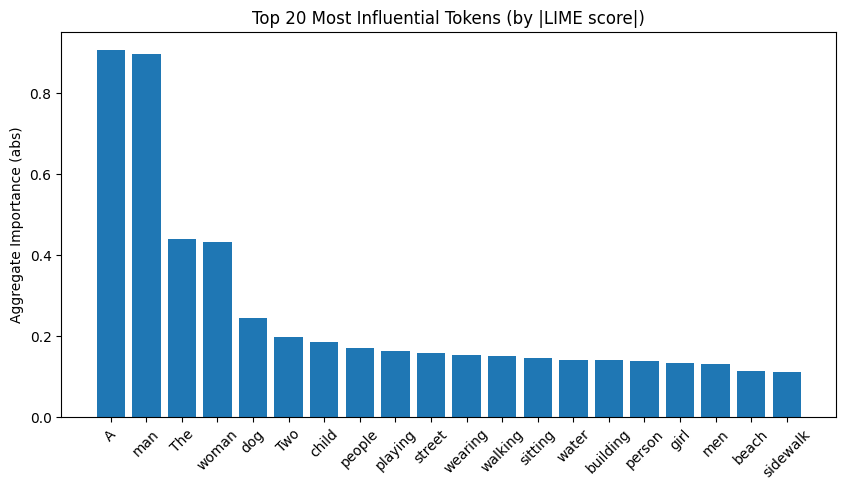

In [28]:
# Aggregate and Plot Top Tokens Across All Samples

import json
from collections import Counter
import matplotlib.pyplot as plt

# Load LIME attributions (path from your earlier code)
with open(lime_attr_filtered_path, "r", encoding="utf-8") as f:
    lime_attributions_filtered = json.load(f)

# Aggregate all tokens and their (absolute) importances
token_counter = Counter()
for ex in lime_attributions_filtered:
    for token, score in ex["attributions"]:
        token_counter[token] += abs(score)

# Get top 20 influential tokens
top_tokens = token_counter.most_common(20)

# Plot
tokens, importances = zip(*top_tokens)
plt.figure(figsize=(10,5))
plt.bar(tokens, importances)
plt.xticks(rotation=45)
plt.title("Top 20 Most Influential Tokens (by |LIME score|)")
plt.ylabel("Aggregate Importance (abs)")
plt.show()

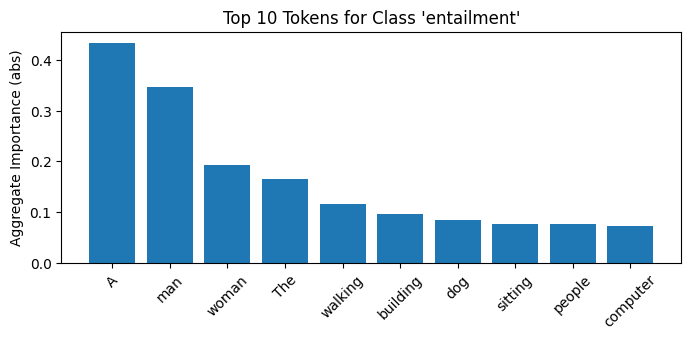

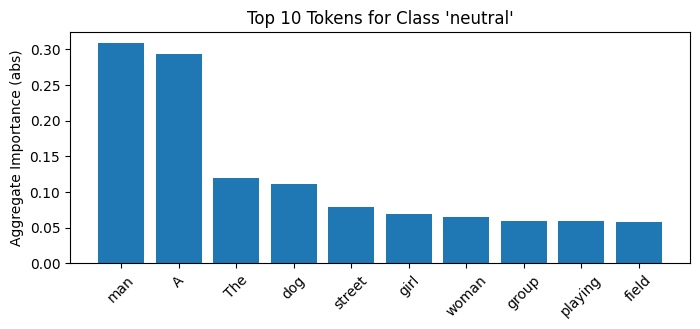

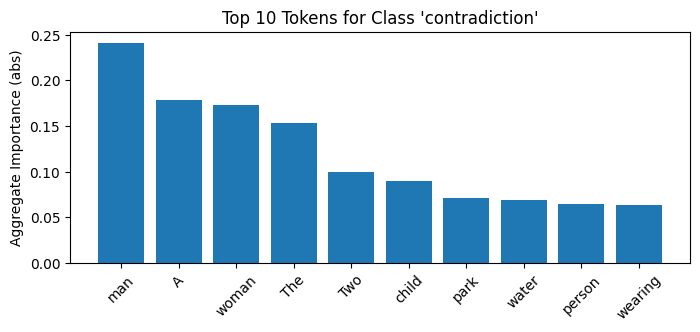

In [29]:
# Compare Attributions by Class

# Group attributions by gold label
from collections import defaultdict

class_token_counter = defaultdict(Counter)
label_map = {0: "entailment", 1: "neutral", 2: "contradiction"}
for ex in lime_attributions_filtered:
    label = ex.get("label")
    if label is not None:
        for token, score in ex["attributions"]:
            class_token_counter[label_map[label]][token] += abs(score)

# Plot for each class
for cls in label_map.values():
    top_cls = class_token_counter[cls].most_common(10)
    tokens, importances = zip(*top_cls)
    plt.figure(figsize=(8,3))
    plt.bar(tokens, importances)
    plt.xticks(rotation=45)
    plt.title(f"Top 10 Tokens for Class '{cls}'")
    plt.ylabel("Aggregate Importance (abs)")
    plt.show()


1. Faithfulness (Sensitivity)
 - How much does removing the top-k most important tokens (by LIME) change the model's prediction?

 - If the prediction changes a lot, the explanation is faithful.

📋 Code Block: Faithfulness Metric

```You can average this over all examples to get a "faithfulness score".```

In [30]:
def compute_faithfulness(model, tokenizer, ex, device, k=3):
    """Compute faithfulness by removing top-k tokens"""
    try:
        if len(ex["attributions"]) < k:
            return 0.0
            
        # Get top-k tokens by absolute importance
        sorted_attrs = sorted(ex["attributions"], key=lambda x: abs(x[1]), reverse=True)
        top_tokens = set([token for token, _ in sorted_attrs[:k]])
        
        orig_text = ex["input_text"]
        
        # Remove top-k tokens
        orig_words = orig_text.split()
        perturbed_words = [w for w in orig_words if w not in top_tokens]
        perturbed_text = " ".join(perturbed_words)
        
        if not perturbed_text.strip():
            return 0.0
        
        # Original prediction
        inputs = tokenizer(orig_text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            orig_logits = model(**inputs).logits
            orig_prob = torch.softmax(orig_logits, dim=1).max().item()
        
        # Perturbed prediction
        inputs_perturbed = tokenizer(perturbed_text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        inputs_perturbed = {k: v.to(device) for k, v in inputs_perturbed.items()}
        
        with torch.no_grad():
            perturbed_logits = model(**inputs_perturbed).logits
            perturbed_prob = torch.softmax(perturbed_logits, dim=1).max().item()
        
        return abs(orig_prob - perturbed_prob)
        
    except Exception as e:
        print(f"Error in faithfulness computation: {e}")
        return 0.0

2. Sufficiency and Comprehensiveness
- Sufficiency: Model prediction using only the top-k tokens.

- Comprehensiveness: Model prediction with top-k tokens removed.

- These two together show how “complete” the explanation is.

📋 Code Block: Sufficiency & Comprehensiveness

```You can plot distributions or means for these metrics.```

In [31]:
def sufficiency(model, tokenizer, ex, device, k=3):
    """Compute sufficiency by keeping only top-k tokens"""
    try:
        if len(ex["attributions"]) < k:
            return 0.0
            
        # Get top-k tokens by absolute importance
        sorted_attrs = sorted(ex["attributions"], key=lambda x: abs(x[1]), reverse=True)
        top_tokens = set([token for token, _ in sorted_attrs[:k]])
        
        orig_text = ex["input_text"]
        orig_words = orig_text.split()
        kept_words = [w for w in orig_words if w in top_tokens]
        new_text = " ".join(kept_words)
        
        if not new_text.strip():
            return 0.0
        
        # Prediction with only top-k tokens
        inputs = tokenizer(new_text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            logits = model(**inputs).logits
            prob = torch.softmax(logits, dim=1).max().item()
        
        return prob
        
    except Exception as e:
        print(f"Error in sufficiency computation: {e}")
        return 0.0

In [32]:
def comprehensiveness(model, tokenizer, ex, device, k=3):
    """Compute comprehensiveness by removing top-k tokens"""
    # This is the same as faithfulness, but we return the remaining probability
    try:
        if len(ex["attributions"]) < k:
            return 0.0
            
        sorted_attrs = sorted(ex["attributions"], key=lambda x: abs(x[1]), reverse=True)
        top_tokens = set([token for token, _ in sorted_attrs[:k]])
        
        orig_text = ex["input_text"]
        orig_words = orig_text.split()
        left_words = [w for w in orig_words if w not in top_tokens]
        new_text = " ".join(left_words)
        
        if not new_text.strip():
            return 0.0
        
        # Prediction with top-k tokens removed
        inputs = tokenizer(new_text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            logits = model(**inputs).logits
            prob = torch.softmax(logits, dim=1).max().item()
        
        return prob
        
    except Exception as e:
        print(f"Error in comprehensiveness computation: {e}")
        return 0.0


## Evaluate LIME Explanations: Faithfulness, Sufficiency, and Comprehensiveness

These metrics measure how much the top-k most important tokens (as identified by LIME) actually affect model predictions.
- **Faithfulness:** How much does removing top-k tokens decrease model confidence?
- **Sufficiency:** How much of the model’s confidence remains if only the top-k tokens are kept?
- **Comprehensiveness:** How much does model confidence drop if top-k tokens are removed?


In [34]:
# Choose an example (e.g., first one)
ex = lime_attributions_filtered[0]
k = 3
USE_PARALLEL = True
device = torch.device("cuda") if not USE_PARALLEL and torch.cuda.is_available() else torch.device("cpu")
faith = compute_faithfulness(model, tokenizer, ex, device, k)
suff = sufficiency(model, tokenizer, ex, device, k)
comp = comprehensiveness(model, tokenizer, ex, device, k)

print(f"Faithfulness: {faith:.4f}")
print(f"Sufficiency: {suff:.4f}")
print(f"Comprehensiveness: {comp:.4f}")

c:\Users\Work\anaconda3\envs\explainable_ai\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Faithfulness: 0.0088
Sufficiency: 0.3649
Comprehensiveness: 0.3862


```Run Metrics for All Examples and Compute Means```

In [35]:
faithfulness_scores = []
sufficiency_scores = []
comprehensiveness_scores = []
k = 3  # Number of top tokens to consider

for i, ex in enumerate(tqdm(lime_attributions_filtered[:50])):  # Test on first 50 examples
    try:
        faith = compute_faithfulness(model, tokenizer, ex, device, k)
        suff = sufficiency(model, tokenizer, ex, device, k)
        comp = comprehensiveness(model, tokenizer, ex, device, k)
        
        faithfulness_scores.append(faith)
        sufficiency_scores.append(suff)
        comprehensiveness_scores.append(comp)
        
    except Exception as e:
        print(f"❌ Error with example ID {ex['id']}: {e}")
        continue

# Calculate and display results
if faithfulness_scores:
    avg_faithfulness = sum(faithfulness_scores) / len(faithfulness_scores)
    avg_sufficiency = sum(sufficiency_scores) / len(sufficiency_scores)
    avg_comprehensiveness = sum(comprehensiveness_scores) / len(comprehensiveness_scores)
    
    print(f"\n📊 EVALUATION RESULTS (k={k}, n={len(faithfulness_scores)} examples):")
    print(f"Average Faithfulness: {avg_faithfulness:.4f}")
    print(f"Average Sufficiency: {avg_sufficiency:.4f}")
    print(f"Average Comprehensiveness: {avg_comprehensiveness:.4f}")
    
    # Save results
    results = {
        "k": k,
        "num_examples": len(faithfulness_scores),
        "avg_faithfulness": avg_faithfulness,
        "avg_sufficiency": avg_sufficiency,
        "avg_comprehensiveness": avg_comprehensiveness,
        "individual_scores": {
            "faithfulness": faithfulness_scores,
            "sufficiency": sufficiency_scores,
            "comprehensiveness": comprehensiveness_scores
        }
    }
    
    results_path = os.path.join(EXPLANATIONS_DIR, "evaluation_results.json")
    with open(results_path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)
    
    print(f"✅ Saved evaluation results to: {results_path}")
else:
    print("❌ No successful evaluations completed")

print("\n🎉 Fixed code execution completed!")

100%|██████████| 50/50 [00:16<00:00,  3.08it/s]


📊 EVALUATION RESULTS (k=3, n=50 examples):
Average Faithfulness: 0.0141
Average Sufficiency: 0.3774
Average Comprehensiveness: 0.3704
✅ Saved evaluation results to: c:\Users\Work\OneDrive\Desktop\ChatGPT\Research\project\data\processed_examples\snli_lime_outputs\evaluation_results.json

🎉 Fixed code execution completed!
